# 01 - Explore the environment

Load one of the fixed mid-size scenarios, look at the rail network and the timetable, then compare
three rollouts on the same seed: random actions, uncoordinated shortest paths, and the OR reference
(prioritized planning + safe-interval search + ordered execution).

Everything here runs in about a minute on a laptop CPU.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from rl_flatland.scenarios import SCENARIOS, make_env
from rl_flatland.graph import RailGraph, to_config
from rl_flatland.plotting import plot_rail
from rl_flatland.deadlock import find_deadlocked
pd.DataFrame({k: v.to_dict() for k, v in SCENARIOS.items()}).T

,name,width,height,n_agents,n_cities,max_rails_between_cities,max_rail_pairs_in_city,speed_ratio_map,malfunction_rate,malfunction_min_duration,malfunction_max_duration
small,small,30,30,10,2,2,2,"{'1.0': 0.25, '0.5': 0.25, '0.3333333333333333...",0.001,20,50
medium,medium,50,50,30,4,2,2,"{'1.0': 0.25, '0.5': 0.25, '0.3333333333333333...",0.001,20,50
large,large,80,80,60,6,2,2,"{'1.0': 0.25, '0.5': 0.25, '0.3333333333333333...",0.001,20,50
xlarge,xlarge,100,100,100,8,2,2,"{'1.0': 0.25, '0.5': 0.25, '0.3333333333333333...",0.001,20,50


## One scenario, one seed

`make_env` builds and resets a `flatland.envs.rail_env.RailEnv`. Every train has a start cell and
heading, a target cell, a speed of 1/k cells per step, an earliest departure (ED) and a latest
arrival (LA). `T` is the episode horizon.

In [2]:
env = make_env("medium", seed=1000)
g = RailGraph(env)
rows = []
for a in env.agents:
    start = to_config(a.initial_configuration)
    k = round(1 / float(a.speed_counter.max_speed))
    d = g.distance(a.handle, start)
    rows.append(dict(train=a.handle, start=start, target=list(a.targets)[0][0], k=k, ED=a.earliest_departure,
                     LA=a.latest_arrival, sp_cells=int(d), slack=a.latest_arrival - a.earliest_departure - k * d))
print(f"T = {env._max_episode_steps} steps, {int(g.is_rail.sum())} rail cells, {int(g.is_switch.sum())} switch cells")
pd.DataFrame(rows).head(12)

T = 475 steps, 255 rail cells, 46 switch cells


,train,start,target,k,ED,LA,sp_cells,slack
0,0,"(10, 31, 1)","(41, 22)",4,11,319,52,100.0
1,1,"(40, 22, 3)","(9, 31)",4,3,384,66,117.0
2,2,"(33, 10, 0)","(11, 31)",1,181,278,49,48.0
3,3,"(8, 31, 1)","(33, 11)",4,15,432,73,125.0
4,4,"(18, 9, 2)","(41, 22)",4,66,291,36,81.0
5,5,"(40, 22, 3)","(18, 10)",3,127,304,36,69.0
6,6,"(10, 31, 3)","(33, 9)",4,22,304,47,94.0
7,7,"(33, 8, 0)","(11, 31)",1,296,393,49,48.0
8,8,"(33, 10, 0)","(11, 31)",2,117,279,49,64.0
9,9,"(10, 31, 1)","(33, 9)",4,9,416,71,123.0


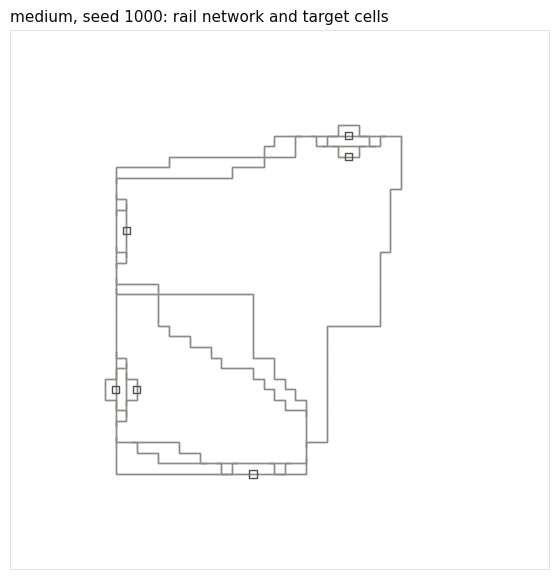

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_rail(env, ax, show_trains=False, title="medium, seed 1000: rail network and target cells");

## Where do trains actually decide?

The RL wrapper asks a train for an action only at departure, at a facing switch, or on the last cell
before a switch. Count how many rail configurations that is.

In [4]:
cfgs = [(r, c, d) for r in range(env.height) for c in range(env.width) for d in range(4)
        if g.is_rail[r, c] and any(env.rail.get_transitions(((r, c), d)))]
dec = sum(g.is_decision_config(c) for c in cfgs)
print(f"{dec} of {len(cfgs)} configurations ({dec / len(cfgs):.0%}) are decision points")

160 of 558 configurations (29%) are decision points


## Three rollouts on the same seed

In [5]:
from rl_flatland.policies import RandomPolicy, ShortestPathPolicy
from rl_flatland.baselines.or_planner import PrioritizedPlannerPolicy

def rollout(policy, seed=1000, snap_at=(0.25, 0.5)):
    env = make_env("medium", seed)
    policy.reset(env)
    snaps, T = {}, env._max_episode_steps
    done = {"__all__": False}
    while not done["__all__"]:
        _, _, done, _ = env.step(policy.act(env))
        policy.observe(env)
        for f in snap_at:
            if env._elapsed_steps == int(f * T):
                fig, ax = plt.subplots(figsize=(4.5, 4.5))
                plot_rail(env, ax, title=f"{policy.name} at {f:.0%} of T")
                snaps[f] = fig
                plt.close(fig)
    graph = getattr(policy, "graph", None) or RailGraph(env)
    arrived = sum(a.state.value == 6 for a in env.agents)
    return env, snaps, arrived, len(find_deadlocked(env, graph))

results = {}
for pol in [RandomPolicy(), ShortestPathPolicy(), PrioritizedPlannerPolicy()]:
    env_p, snaps, arrived, dl = rollout(pol)
    results[pol.name] = (snaps, arrived, dl)
    print(f"{pol.name:15s} arrived {arrived}/{env_p.get_num_agents()}  deadlocked at end: {dl}")

random          arrived 1/30  deadlocked at end: 29


shortest_path   arrived 1/30  deadlocked at end: 23


or_pp_sipp      arrived 30/30  deadlocked at end: 0


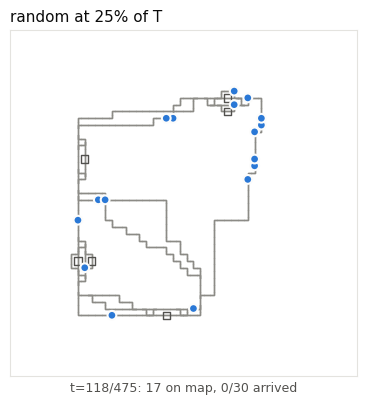

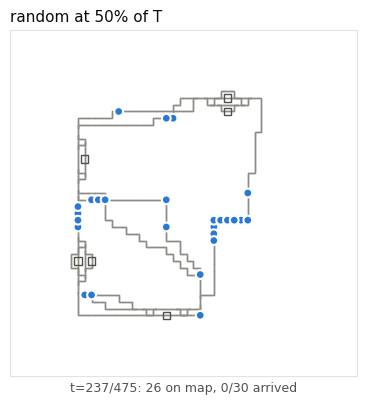

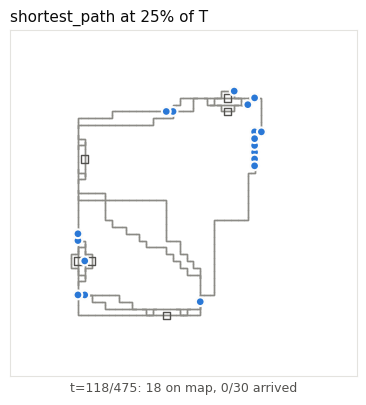

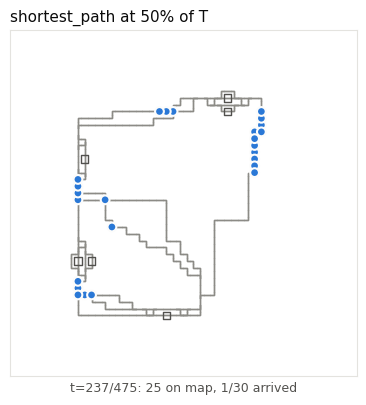

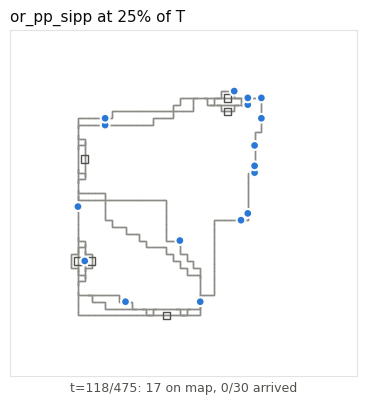

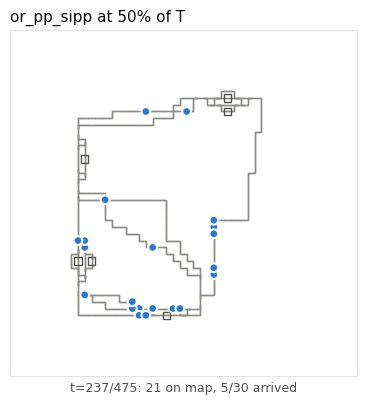

In [6]:
for name, (snaps, _, _) in results.items():
    for f, fig in snaps.items():
        display(fig)

Uncoordinated shortest paths fill the single-track links with head-on pairs within the first
few hundred steps. The OR reference plans every train through a reservation table before the first
step and then only lets a train into a cell after every train planned to use it earlier has left,
so it cannot deadlock even when malfunctions delay trains.